In [1]:
# Supervised ML

### 1) Regression
1) Simple LR
2) Multiple LR
3) Polynomial LR
4) KNN (K-nearset neighbours)
5) Decision tree (DT)
6) Random Forest (RF)
7) SVM (support vector machine)
8) Ensembling algorithm >> bagging & boosting


### 2) Classification
- Logistic regression
- Native bays
- KNN (K-nearset neighbours)
- Decision tree (DT)
- Random Forest (RF)
- SVM (support vector ML)
- Ensembling algorithm >> bagging & boosting

## Linear Regression :-
    - regression means releationship between dependent variable (y) and one or more independent variable (X).
    - if this releationship is linear then called LR
     
- Simple LR >> one dependent and one independent variable
- Multiple LR >> involves multiple independent variable (X)
- Polynomial LR >> relationship between X and y as a nth degree polynomial

#### Simple Linear Regression - one dependent and one independent variable

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# step 1 - data collection

In [4]:
# Load data
df=pd.read_csv('income.csv')
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [5]:
df.shape

(22, 3)

In [6]:
df.dtypes

Name         object
Age           int64
Income($)     int64
dtype: object

In [7]:
df.isnull().sum()

Name         0
Age          0
Income($)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


In [10]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='Income($)'>

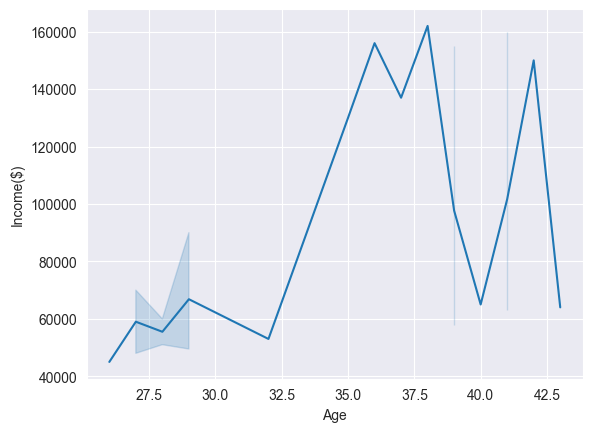

In [11]:
sns.lineplot(data=df, x='Age', y='Income($)')

<Axes: xlabel='Age', ylabel='Income($)'>

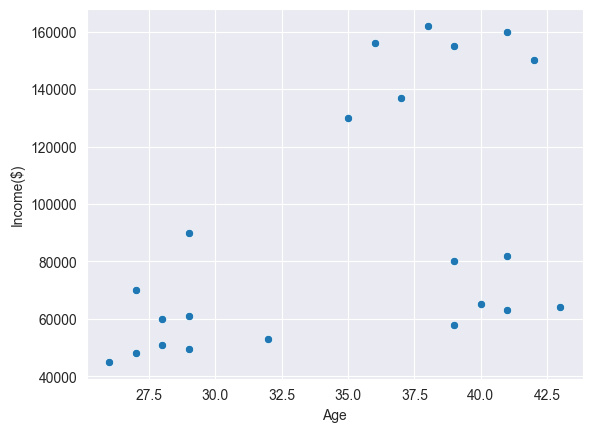

In [12]:
sns.scatterplot(x=df['Age'], y=df['Income($)'])

In [13]:
df.corr(numeric_only=True)

,Age,Income($)
Age,1.000000,0.496856
Income($),0.496856,1.000000


In [14]:
df.drop('Name', axis=1, inplace=True)
df

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [15]:
 # separate X and y

In [16]:
X=df[['Age']]
y=df['Income($)']

In [17]:
X, y

(    Age
 0    27
 1    29
 2    29
 3    28
 4    42
 5    39
 6    41
 7    38
 8    36
 9    35
 10   37
 11   26
 12   27
 13   28
 14   29
 15   32
 16   40
 17   41
 18   43
 19   39
 20   41
 21   39,
 0      70000
 1      90000
 2      61000
 3      60000
 4     150000
 5     155000
 6     160000
 7     162000
 8     156000
 9     130000
 10    137000
 11     45000
 12     48000
 13     51000
 14     49500
 15     53000
 16     65000
 17     63000
 18     64000
 19     80000
 20     82000
 21     58000
 Name: Income($), dtype: int64)

In [18]:
# Encoding (not req)
# Scaling

In [19]:
# train test split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [22]:
X_train.shape, X_test.shape

((17, 1), (5, 1))

In [23]:
y_train.shape, y_test.shape

((17,), (5,))

In [24]:
# model training

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
reg=LinearRegression()

In [27]:
reg.fit(X_train, y_train)

LinearRegression()

In [28]:
m=reg.coef_ # slope >> m
m

array([2889.06831082])

In [29]:
c=reg.intercept_ # intercept >> c
c

np.float64(-15408.10334703463)

In [30]:
# y=mx+c
# age 27 
y=m*27+c
y

array([62596.74104521])

In [31]:
# age 60
y=m*60+c
y

array([157935.99530241])

In [32]:
reg.predict([[27]]) # input should be in 2D format

C:\Users\LENOVO\PycharmProjects\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([62596.74104521])

In [33]:
X_test.shape, y_test.shape

((5, 1), (5,))

In [34]:
reg.score(X_test, y_test) * 100

1.5170668114485752

In [35]:
# score is low 

In [36]:
y_pred=reg.predict(X_test)
y_pred

array([ 65485.80935604,  97265.5607751 ,  91487.42415345, 103043.69739675,
        97265.5607751 ])

In [37]:
y_test

3      60000
5     155000
10    137000
6     160000
21     58000
Name: Income($), dtype: int64

In [38]:
df_test = pd.DataFrame({'actual input':X_test.values.flatten(), 'actual o/p':y_test, 'predicted o/p':y_pred})
df_test

,actual input,actual o/p,predicted o/p
3,28,60000,65485.809356
5,39,155000,97265.560775
10,37,137000,91487.424153
6,41,160000,103043.697397
21,39,58000,97265.560775


In [39]:
# model performance
# score

# regression based

# Metrics

# R2 score
# MAE(mean absolute error)
# MSE(mean squared error)

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [41]:
r2_score(y_test, y_pred)

0.015170668114485752

In [42]:
mean_absolute_error(y_test, y_pred) # average difference

40990.937561166575

In [43]:
mean_squared_error(y_test, y_pred)**0.5

45211.85421171723

In [44]:
# deployment

### Multiple Linear Regression
- multiple input feature (X) and one target variable (y)

In [45]:
# startup profit prediction

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df=pd.read_csv('50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [48]:
df.shape

(50, 5)

In [49]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [50]:
#pd.to_numeric()

In [51]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [54]:
cm=df.corr(numeric_only=True)
cm

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

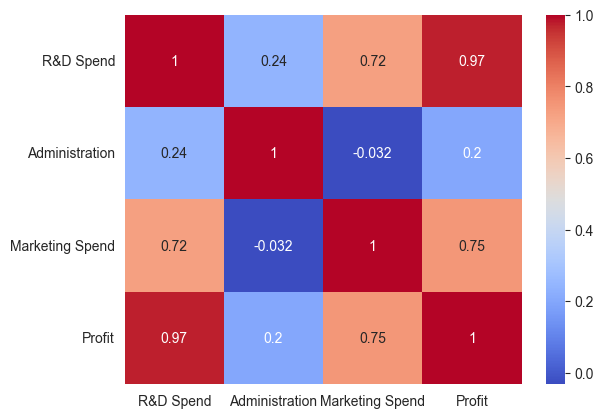

In [55]:
sns.heatmap(cm, annot=True, cmap='coolwarm')

<Axes: xlabel='R&D Spend', ylabel='Profit'>

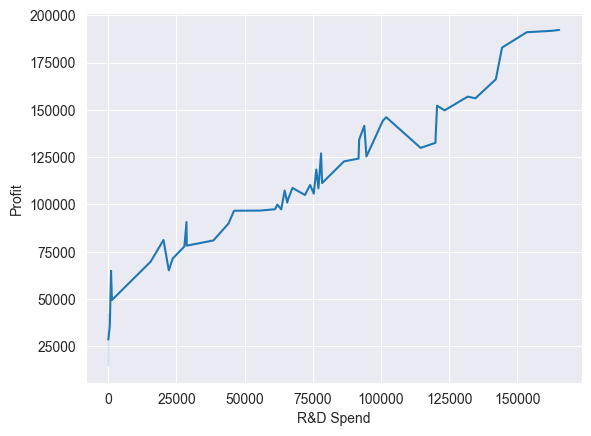

In [56]:
sns.lineplot(data=df, x='R&D Spend', y='Profit')

In [57]:
# feature selection
# feature engineering

In [58]:
# separate X and y
X=df.drop('Profit', axis=1)
y=df['Profit']

In [59]:
# encoding 
from sklearn.preprocessing import OneHotEncoder

In [60]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [61]:
oh=OneHotEncoder(sparse_output=False)

In [62]:
a_en=oh.fit_transform(X[['State']])
a_en

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0

In [63]:
b=oh.get_feature_names_out()
b

array(['State_California', 'State_Florida', 'State_New York'],
      dtype=object)

In [64]:
# X[['State_California', 'State_Florida', 'State_New York']]=a_en
X[b]=a_en
X[b]

,State_California,State_Florida,State_New York
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,0.0,0.0,1.0
6,1.0,0.0,0.0
7,0.0,1.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,0.0


In [65]:
X.drop('State', axis=1, inplace=True)

In [66]:
X

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0.0,0.0,1.0
1,162597.70,151377.59,443898.53,1.0,0.0,0.0
2,153441.51,101145.55,407934.54,0.0,1.0,0.0
3,144372.41,118671.85,383199.62,0.0,0.0,1.0
4,142107.34,91391.77,366168.42,0.0,1.0,0.0
5,131876.90,99814.71,362861.36,0.0,0.0,1.0
6,134615.46,147198.87,127716.82,1.0,0.0,0.0
7,130298.13,145530.06,323876.68,0.0,1.0,0.0
8,120542.52,148718.95,311613.29,0.0,0.0,1.0
9,123334.88,108679.17,304981.62,1.0,0.0,0.0


In [67]:
# Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [68]:
X.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State_California',
       'State_Florida', 'State_New York'],
      dtype='object')

In [69]:
X[['R&D Spend', 'Administration', 'Marketing Spend']]=sc.fit_transform(X[['R&D Spend', 'Administration', 'Marketing Spend']])

In [70]:
X

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,2.016411,0.560753,2.153943,0.0,0.0,1.0
1,1.955860,1.082807,1.923600,1.0,0.0,0.0
2,1.754364,-0.728257,1.626528,0.0,1.0,0.0
3,1.554784,-0.096365,1.422210,0.0,0.0,1.0
4,1.504937,-1.079919,1.281528,0.0,1.0,0.0
5,1.279800,-0.776239,1.254210,0.0,0.0,1.0
6,1.340066,0.932147,-0.688150,1.0,0.0,0.0
7,1.245057,0.871980,0.932186,0.0,1.0,0.0
8,1.030369,0.986952,0.830887,0.0,0.0,1.0
9,1.091819,-0.456640,0.776107,1.0,0.0,0.0


In [71]:
X.describe().round()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
count,50.0,50.0,50.0,50.0,50.0,50.0
mean,-0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,0.0,0.0,0.0
min,-2.0,-3.0,-2.0,0.0,0.0,0.0
25%,-1.0,-1.0,-1.0,0.0,0.0,0.0
50%,-0.0,0.0,0.0,0.0,0.0,0.0
75%,1.0,1.0,1.0,1.0,1.0,1.0
max,2.0,2.0,2.0,1.0,1.0,1.0


In [72]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [73]:
X_train, y_train

(    R&D Spend  Administration  Marketing Spend  State_California  \
 14   1.017181        1.269199         0.375742               0.0   
 42  -1.102106       -0.906938        -0.520596               1.0   
 5    1.279800       -0.776239         1.254210               0.0   
 35  -0.609750       -1.308658        -0.045493               0.0   
 30  -0.258074       -0.205629        -0.990357               0.0   
 9    1.091819       -0.456640         0.776107               1.0   
 43  -1.281134        0.217682        -1.449605               0.0   
 39  -0.773820       -1.383122        -0.297583               1.0   
 49  -1.622362       -0.157226        -1.369985               1.0   
 21   0.102724        1.169186         0.732788               0.0   
 15   0.897913        0.045868         0.419219               0.0   
 0    2.016411        0.560753         2.153943               0.0   
 23  -0.136201       -0.562211         0.774349               0.0   
 41  -1.008534       -1.320796    

In [74]:
# model training
from sklearn.linear_model import LinearRegression

In [75]:
reg=LinearRegression()

In [76]:
reg.fit(X_train, y_train)

LinearRegression()

In [77]:
reg.coef_ #slope

array([37514.6424575 , -1165.33448319,  3141.64657814,  1190.84320777,
         -71.54471732, -1119.29849045])

In [78]:
reg.intercept_

np.float64(110927.17649002453)

In [79]:
reg.score(X_test, y_test)*100

92.86946258325978

In [80]:
# y_pred
y_pred=reg.predict(X_test)
y_pred

array([ 90218.93104586,  44226.43149439,  73160.39175656, 113415.65987268,
       182628.59818796,  46841.05865214, 109227.38565633,  67305.47632997,
       149922.02110832, 113463.14511433])

In [81]:
# y_test >> actual o/p
# y_pred >> predicted o/p

In [82]:
new_df=pd.DataFrame({'actual o/p':y_test, 'pred o/p':y_pred})
new_df

,actual o/p,pred o/p
37,89949.14,90218.931046
45,64926.08,44226.431494
36,90708.19,73160.391757
22,110352.25,113415.659873
2,191050.39,182628.598188
48,35673.41,46841.058652
26,105733.54,109227.385656
38,81229.06,67305.476330
8,152211.77,149922.021108
19,122776.86,113463.145114


In [83]:
x_new=pd.DataFrame([[165349.20, 136897.80 ,471784.10, 'New York']], columns=df.columns[:-1])
x_new

,R&D Spend,Administration,Marketing Spend,State
0,165349.2,136897.8,471784.1,New York


In [84]:
x_new[oh.get_feature_names_out()]=oh.transform(x_new[['State']])

In [85]:
oh.get_feature_names_out()

array(['State_California', 'State_Florida', 'State_New York'],
      dtype=object)

In [86]:
x_new

,R&D Spend,Administration,Marketing Spend,State,State_California,State_Florida,State_New York
0,165349.2,136897.8,471784.1,New York,0.0,0.0,1.0


In [87]:
x_new.drop('State', inplace=True, axis=1)

In [88]:
x_new

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.2,136897.8,471784.1,0.0,0.0,1.0


In [89]:
x_new[['R&D Spend', 'Administration', 'Marketing Spend']]=sc.transform(x_new[['R&D Spend', 'Administration', 'Marketing Spend']])

In [90]:
x_new

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,2.016411,0.560753,2.153943,0.0,0.0,1.0


In [91]:
reg.predict(x_new)

array([191566.29743847])

In [92]:
# performance of model
# score, r2 score, mae, rmse 

In [93]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [94]:
r2_score(y_test, y_pred)

0.9286946258325978

In [95]:
mean_absolute_error(y_test, y_pred)

9019.098123548694

In [96]:
mean_squared_error(y_test, y_pred)**0.5

11133.563073395982

### pickle (byte format)

In [97]:
import pickle

In [98]:
with open('startup_model', 'wb',) as f:
    pickle.dump(reg, f)

In [99]:
# deployment

In [100]:
with open('oh_pickle', 'wb') as f:
    pickle.dump(oh, f)

In [101]:
with open('sc_pickle', 'wb') as f:
    pickle.dump(sc, f)

In [102]:
# tkinter >> GUI 

### polynomial regression

In [103]:
import pandas as pd
import numpy as np

In [104]:
# mileage prediction system
df=pd.read_csv('mtcars.csv')
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [105]:
df.shape

(32, 11)

In [106]:
df.dtypes

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [107]:
df.isnull().sum()

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

In [108]:
df.duplicated().sum()

np.int64(0)

In [110]:
df.describe().round()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0,32.0
mean,20.0,6.0,231.0,147.0,4.0,3.0,18.0,0.0,0.0,4.0,3.0
std,6.0,2.0,124.0,69.0,1.0,1.0,2.0,1.0,0.0,1.0,2.0
min,10.0,4.0,71.0,52.0,3.0,2.0,14.0,0.0,0.0,3.0,1.0
25%,15.0,4.0,121.0,96.0,3.0,3.0,17.0,0.0,0.0,3.0,2.0
50%,19.0,6.0,196.0,123.0,4.0,3.0,18.0,0.0,0.0,4.0,2.0
75%,23.0,8.0,326.0,180.0,4.0,4.0,19.0,1.0,1.0,4.0,4.0
max,34.0,8.0,472.0,335.0,5.0,5.0,23.0,1.0,1.0,5.0,8.0


In [111]:
X=df.drop('mpg', axis=1)
y=df['mpg']

In [112]:
X, y

(    cyl   disp   hp  drat     wt   qsec  vs  am  gear  carb
 0     6  160.0  110  3.90  2.620  16.46   0   1     4     4
 1     6  160.0  110  3.90  2.875  17.02   0   1     4     4
 2     4  108.0   93  3.85  2.320  18.61   1   1     4     1
 3     6  258.0  110  3.08  3.215  19.44   1   0     3     1
 4     8  360.0  175  3.15  3.440  17.02   0   0     3     2
 5     6  225.0  105  2.76  3.460  20.22   1   0     3     1
 6     8  360.0  245  3.21  3.570  15.84   0   0     3     4
 7     4  146.7   62  3.69  3.190  20.00   1   0     4     2
 8     4  140.8   95  3.92  3.150  22.90   1   0     4     2
 9     6  167.6  123  3.92  3.440  18.30   1   0     4     4
 10    6  167.6  123  3.92  3.440  18.90   1   0     4     4
 11    8  275.8  180  3.07  4.070  17.40   0   0     3     3
 12    8  275.8  180  3.07  3.730  17.60   0   0     3     3
 13    8  275.8  180  3.07  3.780  18.00   0   0     3     3
 14    8  472.0  205  2.93  5.250  17.98   0   0     3     4
 15    8  460.0  215  3.

In [113]:
#encoding

In [114]:
#scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [116]:
X_sc=sc.fit_transform(X)
X_sc

array([[-1.06667720e-01, -5.79750316e-01, -5.43654869e-01,
         5.76594481e-01, -6.20166581e-01, -7.89600577e-01,
        -8.81917104e-01,  1.20894105e+00,  4.30331483e-01,
         7.46967077e-01],
       [-1.06667720e-01, -5.79750316e-01, -5.43654869e-01,
         5.76594481e-01, -3.55382189e-01, -4.71201785e-01,
        -8.81917104e-01,  1.20894105e+00,  4.30331483e-01,
         7.46967077e-01],
       [-1.24445674e+00, -1.00602601e+00, -7.95569902e-01,
         4.81584062e-01, -9.31677630e-01,  4.32823359e-01,
         1.13389342e+00,  1.20894105e+00,  4.30331483e-01,
        -1.14010764e+00],
       [-1.06667720e-01,  2.23615417e-01, -5.43654869e-01,
        -9.81576392e-01, -2.33633287e-03,  9.04735855e-01,
         1.13389342e+00, -8.27170192e-01, -9.46729262e-01,
        -1.14010764e+00],
       [ 1.03112130e+00,  1.05977159e+00,  4.19549669e-01,
        -8.48561806e-01,  2.31296954e-01, -4.71201785e-01,
        -8.81917104e-01, -8.27170192e-01, -9.46729262e-01,
        -5.

In [118]:
# train test split
from sklearn.model_selection import train_test_split

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.20, random_state=0)

In [120]:
X_train.shape, X_test.shape

((25, 10), (7, 10))

In [121]:
y_train.shape, y_test.shape

((25,), (7,))

In [125]:
#model training
from sklearn.preprocessing import PolynomialFeatures
p1=PolynomialFeatures()
p1.fit_transform(X_train)
x_train_new = p1.transform(X_train)
x_test_new=p1.transform(X_test)

In [126]:
x_train_new.shape, x_test_new.shape

((25, 66), (7, 66))

In [127]:
# model selection
from sklearn.linear_model import LinearRegression

In [128]:
reg=LinearRegression()

In [129]:
reg.fit(x_train_new, y_train)

LinearRegression()

In [130]:
reg.score(x_test_new, y_test)

-0.34534631827411344

In [131]:
y_pred=reg.predict(x_test_new)

In [132]:
# model performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [133]:
r2_score(y_test, y_pred)

-0.34534631827411344

In [134]:
mean_absolute_error(y_test, y_pred)

3.320456955209351

In [139]:
mse=mean_squared_error(y_test, y_pred)
np.sqrt(mse)

np.float64(3.9987314030073984)

In [142]:
# model is overfitted

In [143]:
reg.score(x_train_new, y_train)

1.0

### Overfitted
- when is too good on training data and bad on testing data

### Underfitted
- bad on training data and testing data

### Good model
- good on training as well as testing data

### how to handle overfitting
- regulization technique - ridge, lassa
- cross validation
- sampling technique
- feature selection (filter method)
- dimension reduction algorithm(PCA, LDA)
- ensembling algorithm
- hyper parameter tuning

## Ridge

In [144]:
from sklearn.linear_model import Ridge

In [150]:
rg=Ridge(alpha=5.0)
rg.fit(x_train_new, y_train)

Ridge(alpha=5.0)

In [151]:
rg.score(x_train_new, y_train)

0.9438870534392647

In [152]:
rg.score(x_test_new, y_test)

0.5155339648838113

In [158]:
from sklearn.linear_model import Lasso
ls=Lasso(alpha=1.0)

In [159]:
ls.fit(x_train_new, y_train)

Lasso()

In [160]:
ls.score(x_train_new, y_train)

0.8305785506344779

In [161]:
ls.score(x_test_new, y_test)

0.5205546368085119